<a href="https://colab.research.google.com/github/jhagihara/Hockey-Predictions/blob/main/hockey_analysis_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Prep

In [ ]:
import pandas as pd
url = 'https://nuhuskies.com/sports/womens-ice-hockey/stats/2023-24/connecticut/boxscore/12666'
nu_wih = pd.read_html(url)
len(nu_wih)

14

In [ ]:
# Now to build a big loop for all the games
opponents = ['penn-state', 'penn-state', 'liu', 'liu',
             'boston-university', 'boston-university', 'merrimack',
             'st-cloud-state', 'sacred-heart', 'holy-cross', 'holy-cross',
             'connecticut', 'connecticut', 'providence', 'providence',
             'vermont', 'boston-college', 'providence', 'boston-university',
             'yale', 'holy-cross', 'maine', 'maine', 'harvard', 'new-hampshire',
             'boston-university', 'merrimack', 'merrimack', 'new-hampshire',
             'new-hampshire', 'connecticut', 'maine', 'boston-college',
             'boston-college', 'vermont', 'vermont', 'merrimack', 'new-hampshire',
             'connecticut', 'penn-state', 'penn-state', 'quinnipiac', 'quinnipiac',
             'boston-university', 'boston-university', 'holy-cross', 'holy-cross']

game_numbers = [12650, 12653, 12654, 12655, 12656, 12657, 12658,
                12660, 12662, 12663, 12664, 12665, 12666, 12668,
                12671, 12673, 12675, 12677, 12678, 12679, 12680,
                12681, 12682, 12683, 12684, 12685, 12686, 12687,
                12688, 12689, 12690, 12691, 12692, 12693, 12694,
                12695, 13051, 13103, 13104, 13184, 13185, 13186,
                13187, 13188, 13189, 13190, 13191]


In [ ]:
# Nested dictionary
from datetime import timedelta
from collections import defaultdict
full_dict = defaultdict(dict)

# The Loop
for idx in range(len(game_numbers)):
    year = "2024-25" if game_numbers[idx] > 13104 else "2023-24"
    url = f'https://nuhuskies.com/sports/womens-ice-hockey/stats/{year}/{opponents[idx]}/boxscore/{game_numbers[idx]}'
    nu_wih = pd.read_html(url)

    # Initialize a dictionary with lists as default values (though lists are not needed here)
    test_dict = defaultdict(list)

    # Clean up the team names by removing "Winner " from the "Team" column in nu_wih[0]
    nu_wih[0].iloc[:, 0] = nu_wih[0].iloc[:, 0].str.replace("Winner  ", "")

    # Assign home and visit teams to the dictionary
    test_dict['home_team'] = nu_wih[0].loc[1, "Team"]
    test_dict['visit_team'] = nu_wih[0].loc[0, "Team"]

    # Extract linescores for home and visit teams
    home_linescore = nu_wih[0].iloc[1, 1:-1]
    visit_linescore = nu_wih[0].iloc[0, 1:-1]

    # Assign home linescore values to the dictionary
    for col in home_linescore.index:
        col2 = "home_" + col  # Create a key like "home_1st", "home_2nd", etc.
        test_dict[col2] = home_linescore[col]  # Direct assignment

    # Assign visit linescore values to the dictionary
    for col in visit_linescore.index:
        col2 = "visit_" + col  # Create a key like "visit_1st", "visit_2nd", etc.
        test_dict[col2] = visit_linescore[col]  # Direct assignment

    # Function to convert the time string (e.g., "02:30") into a timedelta object
    def convert_to_timedelta(time_str):
        minutes, seconds = map(int, time_str.split(':'))
        return timedelta(minutes=minutes, seconds=seconds)

    # Function to format timedelta as "MM:SS"
    def format_timedelta(td):
        total_seconds = int(td.total_seconds())
        minutes, seconds = divmod(total_seconds, 60)
        return f"{minutes:02}:{seconds:02}"

    # Process home team's power play stats by period from nu_wih[3]
    df_home = nu_wih[3].iloc[:-1, :]  # Exclude last row

    if 'Prd' in df_home.columns:
        for period in df_home['Prd'].unique():
            i = int(period[0])  # Extract the period number (e.g., 1st -> 1)

            # Filter the data for the specific period
            period_df = df_home[df_home['Prd'] == period]

            # Sum shots, opp-shots, and calculate total elapsed power play time
            shots_sum = period_df['Shots'].sum()
            opp_shots_sum = period_df['Opp-Shots'].sum()
            total_elapsed = sum(period_df['Elapsed'].apply(convert_to_timedelta), timedelta())
            total_elapsed_str = format_timedelta(total_elapsed)

            # Store the calculated values in the dictionary
            test_dict[f'home_pp_elapsed_{i}'] = total_elapsed_str
            test_dict[f'home_pp_shots_{i}'] = shots_sum
            test_dict[f'home_pp_oppshots_{i}'] = opp_shots_sum
    else:
        test_dict[f'home_pp_elapsed_{i}'] = '00:00'
        test_dict[f'home_pp_shots_{i}'] = 0
        test_dict[f'home_pp_oppshots_{i}'] = 0

    # Process visit team's power play stats by period from nu_wih[2]
    df_visit = nu_wih[2].iloc[:-1, :]  # Exclude last row

    if 'Prd' in df_visit.columns:
        for period in df_visit['Prd'].unique():
            i = int(period[0])  # Extract the period number

            # Filter the data for the specific period
            period_df = df_visit[df_visit['Prd'] == period]

            # Sum shots, opp-shots, and calculate total elapsed power play time
            shots_sum = period_df['Shots'].sum()
            opp_shots_sum = period_df['Opp-Shots'].sum()
            total_elapsed = sum(period_df['Elapsed'].apply(convert_to_timedelta), timedelta())
            total_elapsed_str = format_timedelta(total_elapsed)

            # Store the calculated values in the dictionary
            test_dict[f'visit_pp_elapsed_{i}'] = total_elapsed_str
            test_dict[f'visit_pp_shots_{i}'] = shots_sum
            test_dict[f'visit_pp_oppshots_{i}'] = opp_shots_sum
    else:
        test_dict[f'visit_pp_elapsed_{i}'] = '00:00'
        test_dict[f'visit_pp_shots_{i}'] = 0
        test_dict[f'visit_pp_oppshots_{i}'] = 0
    # Process home team performance data from nu_wih[6]
    df_home_perf = nu_wih[6].iloc[-1, :]  # Last row

    # Keep relevant columns ('A', 'Shots By Period', 'BLK')
    columns_to_keep = df_home_perf.loc[df_home_perf.index.get_level_values(0).isin(['A', 'Shots By Period', 'BLK'])]

    # Store home team performance data in the dictionary
    for col in columns_to_keep.index:
        if col[0] == 'Shots By Period':
            test_dict[f"home_shots_p{col[1]}"] = columns_to_keep[col]
        else:
            test_dict[f'home_{col[0]}'] = columns_to_keep[col]

    # Process visit team performance data from nu_wih[5]
    df_visit_perf = nu_wih[5].iloc[-1, :]  # Last row

    # Keep relevant columns ('A', 'Shots By Period', 'BLK')
    columns_to_keep = df_visit_perf.loc[df_visit_perf.index.get_level_values(0).isin(['A', 'Shots By Period', 'BLK'])]

    # Store visit team performance data in the dictionary
    for col in columns_to_keep.index:
        if col[0] == 'Shots By Period':
            test_dict[f"visit_shots_p{col[1]}"] = columns_to_keep[col]
        else:
            test_dict[f'visit_{col[0]}'] = columns_to_keep[col]

    # Store faceoff wins for home and visit teams
    test_dict['home_faceoff_w'] = nu_wih[9].iloc[-1, -1]  # Last row, last column
    test_dict['visit_faceoff_w'] = nu_wih[9].iloc[-1, -2]  # Last row, second-to-last column

    print(f'Index {idx} worked, moving to {idx+1}')
    full_dict[f'game_{idx}'] = test_dict

Index 0 worked, moving to 1
Index 1 worked, moving to 2
Index 2 worked, moving to 3
Index 3 worked, moving to 4
Index 4 worked, moving to 5
Index 5 worked, moving to 6
Index 6 worked, moving to 7
Index 7 worked, moving to 8
Index 8 worked, moving to 9
Index 9 worked, moving to 10
Index 10 worked, moving to 11
Index 11 worked, moving to 12
Index 12 worked, moving to 13
Index 13 worked, moving to 14
Index 14 worked, moving to 15
Index 15 worked, moving to 16
Index 16 worked, moving to 17
Index 17 worked, moving to 18
Index 18 worked, moving to 19
Index 19 worked, moving to 20
Index 20 worked, moving to 21
Index 21 worked, moving to 22
Index 22 worked, moving to 23
Index 23 worked, moving to 24
Index 24 worked, moving to 25
Index 25 worked, moving to 26
Index 26 worked, moving to 27
Index 27 worked, moving to 28
Index 28 worked, moving to 29
Index 29 worked, moving to 30
Index 30 worked, moving to 31
Index 31 worked, moving to 32
Index 32 worked, moving to 33
Index 33 worked, moving to 34

In [ ]:
full_dict

defaultdict(dict,
            {'game_0': defaultdict(list,
                         {'home_team': 'Northeastern',
                          'visit_team': 'Penn St.',
                          'home_1': 1,
                          'home_2': 0,
                          'home_3': 0,
                          'visit_1': 0,
                          'visit_2': 0,
                          'visit_3': 0,
                          'home_pp_elapsed_1': '04:05',
                          'home_pp_shots_1': 4,
                          'home_pp_oppshots_1': 0,
                          'home_pp_elapsed_2': '02:00',
                          'home_pp_shots_2': 1,
                          'home_pp_oppshots_2': 0,
                          'home_pp_elapsed_3': '00:40',
                          'home_pp_shots_3': 0,
                          'home_pp_oppshots_3': 1,
                          'visit_pp_elapsed_1': '02:00',
                          'visit_pp_shots_1': 2,
                          

In [ ]:
# Convert the nested dictionary into a DataFrame
df_2023_24 = pd.DataFrame.from_dict(full_dict, orient='index')

# Adding the latest games of the 2425 season
'''
df_2023_24.loc[len(df_2023_24)] = ['Northeastern', 'Quinnipiac',
                                   2, 0, 2, 1, 0, 1,
                                   02.14, 3, 0, 00.00, 0, 0, 00.00, 0, 0,
                                   00.22, 1, 0, 02.00, 5, 0, 03.50, 7, 0,
                                   6, 8, 7, 9, 14, 4, 10, 11, 14, 10, 30, 28,
                                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
df_2023_24.loc[len(df_2023_24)] = ['Northeastern', 'Quinnipiac',
                                   0, 0, 0, 0, 2, 1,
                                   04.00, 2, 0, 01.47, 1, 0, 00.00, 0, 0,
                                   00.00, 0, 0, 01.47, 0, 0, 00.38, 1, 0,
                                   0, 8, 9, 11, 17, 5, 8, 11, 7, 9, 25, 36,
                                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

df_2023_24.loc[len(df_2023_24)] = ['Northeastern', 'Boston University',
                                   1, 2, 1, 0, 0, 0,
                                   02.00, 1, 0, 02.00, 2, 0, 02.00, 2, 0,
                                   00.20, 2, 0, 02.00, 0, 0, 02.00, 7, 0,
                                   7, 10, 8, 8, 9, 0, 8, 7, 11, 11, 26, 32,
                                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
'''


# Display the DataFrame
df_2023_24.head()

# Checking if the last row in the dataframe was added correctly
last_row = df_2023_24.tail(1)
print(last_row)

            home_team  visit_team  home_1  home_2  home_3  visit_1  visit_2  \
game_46  Northeastern  Holy Cross       0       0       4        0        1   

         visit_3 home_pp_elapsed_1  home_pp_shots_1  ...  visit_OT 1  \
game_46        1             02:00              1.0  ...         NaN   

        visit_pp_elapsed_4  visit_pp_shots_4  visit_pp_oppshots_4  \
game_46                NaN               NaN                  NaN   

        home_shots_p4  visit_shots_p4  home_OT 2 visit_OT 2  home_shots_p5  \
game_46           NaN             NaN        NaN        NaN            NaN   

         visit_shots_p5  
game_46             NaN  

[1 rows x 49 columns]


In [ ]:
import numpy as np

# make a list of all entries for home_team and visit_team
home_teams = df_2023_24['home_team'].unique()
visit_teams = df_2023_24['visit_team'].unique()
all_teams = np.concatenate((home_teams, visit_teams))

In [ ]:
df_2023_24.columns

Index(['home_team', 'visit_team', 'home_1', 'home_2', 'home_3', 'visit_1',
       'visit_2', 'visit_3', 'home_pp_elapsed_1', 'home_pp_shots_1',
       'home_pp_oppshots_1', 'home_pp_elapsed_2', 'home_pp_shots_2',
       'home_pp_oppshots_2', 'home_pp_elapsed_3', 'home_pp_shots_3',
       'home_pp_oppshots_3', 'visit_pp_elapsed_1', 'visit_pp_shots_1',
       'visit_pp_oppshots_1', 'visit_pp_elapsed_2', 'visit_pp_shots_2',
       'visit_pp_oppshots_2', 'visit_pp_elapsed_3', 'visit_pp_shots_3',
       'visit_pp_oppshots_3', 'home_A', 'home_shots_p1', 'home_shots_p2',
       'home_shots_p3', 'home_BLK', 'visit_A', 'visit_shots_p1',
       'visit_shots_p2', 'visit_shots_p3', 'visit_BLK', 'home_faceoff_w',
       'visit_faceoff_w', 'home_OT 1', 'visit_OT 1', 'visit_pp_elapsed_4',
       'visit_pp_shots_4', 'visit_pp_oppshots_4', 'home_shots_p4',
       'visit_shots_p4', 'home_OT 2', 'visit_OT 2', 'home_shots_p5',
       'visit_shots_p5'],
      dtype='object')

In [ ]:
# Build a (very) basic model to predict the winner of a game
# This model will be BAD, but will give you some sense of how to start with building these types of models
# First of all, you'll want to do MUCH more cleaning than the below...
# Need to first get the final score:
home_score = df_2023_24.home_1 + df_2023_24.home_2 + df_2023_24.home_3 + df_2023_24['home_OT 1'].fillna(0) + df_2023_24['home_OT 2'].fillna(0)
visit_score = df_2023_24.visit_1 + df_2023_24.visit_2 + df_2023_24.visit_3 + df_2023_24['visit_OT 1'].fillna(0) + df_2023_24['visit_OT 2'].fillna(0)
home_team_W = (home_score > visit_score).astype(int)
home_team_W

,0
game_0,1
game_1,0
game_2,0
game_3,0
game_4,0
game_5,1
game_6,1
game_7,0
game_8,0
game_9,0


In [ ]:
# Check some intuitive features and compare their values in wins vs losses
import numpy as np
Choose_stat = 'home_pp_shots_1' # for example, home_pp_shots_1

Win_rows = home_team_W == 1
Loss_rows = home_team_W == 0
Stat_mean_wins = df_2023_24.loc[Win_rows,Choose_stat].mean()
Stat_mean_losses = df_2023_24.loc[Loss_rows,Choose_stat].mean()
Stat_diff_standard_error = np.sqrt((df_2023_24.loc[Win_rows,Choose_stat].var()/sum(Win_rows)) + (df_2023_24.loc[Loss_rows,Choose_stat].var()/sum(Loss_rows)))
if np.abs((Stat_mean_wins - Stat_mean_losses)/Stat_diff_standard_error) > 3:
    Big_diff = 'a BIG'
else:
    Big_diff = 'not that big a'

print(f'The mean value for {Choose_stat} in wins: {Stat_mean_wins} \nThe mean value for {Choose_stat} in losses: {Stat_mean_losses} \nThis is {Big_diff} difference')

The mean value for home_pp_shots_1 in wins: 1.8461538461538463 
The mean value for home_pp_shots_1 in losses: 3.0625 
This is not that big a difference


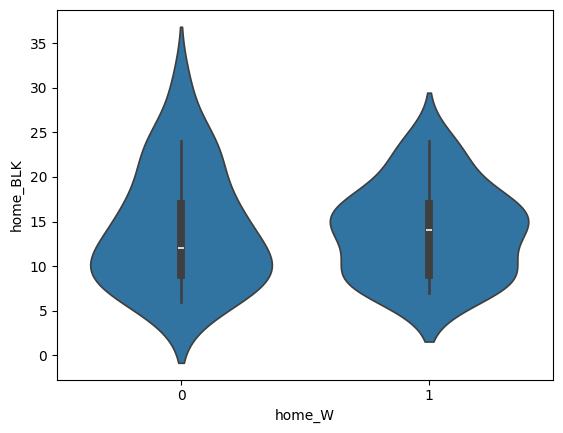

In [ ]:
# Can also make some plots
import seaborn as sns

# add the win column to the data
df_new = df_2023_24
df_new['home_W'] = home_team_W
sns.violinplot(data=df_new, x="home_W", y="home_BLK");

In [ ]:
df_new.isna().sum()

,0
home_team,0
visit_team,0
home_1,0
home_2,0
home_3,0
visit_1,0
visit_2,0
visit_3,0
home_pp_elapsed_1,18
home_pp_shots_1,18


In [ ]:
#impute all missing values with 0
df_new = df_new.fillna(0)
df_new.isna().sum()

,0
home_team,0
visit_team,0
home_1,0
home_2,0
home_3,0
visit_1,0
visit_2,0
visit_3,0
home_pp_elapsed_1,0
home_pp_shots_1,0


In [ ]:
df_new.duplicated().sum()

0

In [ ]:
df_new.columns

Index(['home_team', 'visit_team', 'home_1', 'home_2', 'home_3', 'visit_1',
       'visit_2', 'visit_3', 'home_pp_elapsed_1', 'home_pp_shots_1',
       'home_pp_oppshots_1', 'home_pp_elapsed_2', 'home_pp_shots_2',
       'home_pp_oppshots_2', 'home_pp_elapsed_3', 'home_pp_shots_3',
       'home_pp_oppshots_3', 'visit_pp_elapsed_1', 'visit_pp_shots_1',
       'visit_pp_oppshots_1', 'visit_pp_elapsed_2', 'visit_pp_shots_2',
       'visit_pp_oppshots_2', 'visit_pp_elapsed_3', 'visit_pp_shots_3',
       'visit_pp_oppshots_3', 'home_A', 'home_shots_p1', 'home_shots_p2',
       'home_shots_p3', 'home_BLK', 'visit_A', 'visit_shots_p1',
       'visit_shots_p2', 'visit_shots_p3', 'visit_BLK', 'home_faceoff_w',
       'visit_faceoff_w', 'home_OT 1', 'visit_OT 1', 'visit_pp_elapsed_4',
       'visit_pp_shots_4', 'visit_pp_oppshots_4', 'home_shots_p4',
       'visit_shots_p4', 'home_OT 2', 'visit_OT 2', 'home_shots_p5',
       'visit_shots_p5', 'home_W'],
      dtype='object')

In [ ]:
# make new column "saves"
df_new['home_saves_1'] = df_new['home_shots_p1'] - df_new['home_1']
df_new['home_saves_2'] = df_new['home_shots_p2'] - df_new['home_2']
df_new['home_saves_3'] = df_new['home_shots_p3'] - df_new['home_3']
df_new['visit_saves_1'] = df_new['visit_shots_p1'] - df_new['visit_1']
df_new['visit_saves_2'] = df_new['visit_shots_p2'] - df_new['visit_2']
df_new['visit_saves_3'] = df_new['visit_shots_p3'] - df_new['visit_3']


In [ ]:
df_new.columns

Index(['home_team', 'visit_team', 'home_1', 'home_2', 'home_3', 'visit_1',
       'visit_2', 'visit_3', 'home_pp_elapsed_1', 'home_pp_shots_1',
       'home_pp_oppshots_1', 'home_pp_elapsed_2', 'home_pp_shots_2',
       'home_pp_oppshots_2', 'home_pp_elapsed_3', 'home_pp_shots_3',
       'home_pp_oppshots_3', 'visit_pp_elapsed_1', 'visit_pp_shots_1',
       'visit_pp_oppshots_1', 'visit_pp_elapsed_2', 'visit_pp_shots_2',
       'visit_pp_oppshots_2', 'visit_pp_elapsed_3', 'visit_pp_shots_3',
       'visit_pp_oppshots_3', 'home_A', 'home_shots_p1', 'home_shots_p2',
       'home_shots_p3', 'home_BLK', 'visit_A', 'visit_shots_p1',
       'visit_shots_p2', 'visit_shots_p3', 'visit_BLK', 'home_faceoff_w',
       'visit_faceoff_w', 'home_OT 1', 'visit_OT 1', 'visit_pp_elapsed_4',
       'visit_pp_shots_4', 'visit_pp_oppshots_4', 'home_shots_p4',
       'visit_shots_p4', 'home_OT 2', 'visit_OT 2', 'home_shots_p5',
       'visit_shots_p5', 'home_W', 'home_saves_1', 'home_saves_2',
       'home

In [ ]:
import pandas as pd  # import pandas

# Convert all pp_elapsed columns to total seconds
for column in df_new.columns:
    if 'pp_elapsed' in column:
        # Convert to timedelta first
        df_new[column] = pd.to_timedelta(df_new[column], errors='coerce')
        # Then extract total seconds
        df_new[column] = df_new[column].dt.total_seconds()


In [ ]:
# calculates the point differential for home and away
for i in range(3):
  df_new['home_plus_minus'] = df_new['home_' + str(i+1)] - df_new['visit_' + str(i+1)]
  df_new['visit_plus_minus'] = df_new['visit_' + str(i+1)] - df_new['home_' + str(i+1)]
# List of all home columns
new_cols_home = df_new.columns[df_new.columns.str.startswith('home')].tolist()
# List of all visit columns
new_cols_visit = df_new.columns[df_new.columns.str.startswith('visit')].tolist()
# list of all
pred_cols = new_cols_visit + new_cols_home



1.   Train test split
2.   scale data
3.   PCA?????? (if needed)
4.   Possible algorithms: decision tree, random forest, SVM, neural network (down the line)
5.   Make a predictor function



In [ ]:
#train test split
from sklearn.model_selection import train_test_split
X = df_new.drop(columns=['home_W'])
y = df_new['home_W']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
# getting dummy variables
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [ ]:
# x train and x test have the same columns
for col in X_train.columns:
    if col not in X_test.columns:
        X_test[col] = 0


In [ ]:
# size of X train and test
print(X_train.shape)
print(X_test.shape)

(37, 78)
(10, 81)


In [ ]:
# size of y train and test
print(y_train.shape)
print(y_test.shape)

(37,)
(10,)


In [ ]:
print(X_train.columns)
print(X_test.columns)

Index(['home_1', 'home_2', 'home_3', 'visit_1', 'visit_2', 'visit_3',
       'home_pp_elapsed_1', 'home_pp_shots_1', 'home_pp_oppshots_1',
       'home_pp_elapsed_2', 'home_pp_shots_2', 'home_pp_oppshots_2',
       'home_pp_elapsed_3', 'home_pp_shots_3', 'home_pp_oppshots_3',
       'visit_pp_elapsed_1', 'visit_pp_shots_1', 'visit_pp_oppshots_1',
       'visit_pp_elapsed_2', 'visit_pp_shots_2', 'visit_pp_oppshots_2',
       'visit_pp_elapsed_3', 'visit_pp_shots_3', 'visit_pp_oppshots_3',
       'home_A', 'home_shots_p1', 'home_shots_p2', 'home_shots_p3', 'home_BLK',
       'visit_A', 'visit_shots_p1', 'visit_shots_p2', 'visit_shots_p3',
       'visit_BLK', 'home_faceoff_w', 'visit_faceoff_w', 'home_OT 1',
       'visit_OT 1', 'visit_pp_elapsed_4', 'visit_pp_shots_4',
       'visit_pp_oppshots_4', 'home_shots_p4', 'visit_shots_p4', 'home_OT 2',
       'visit_OT 2', 'home_shots_p5', 'visit_shots_p5', 'home_saves_1',
       'home_saves_2', 'home_saves_3', 'visit_saves_1', 'visit_saves_2',

In [ ]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
# metric function for precision, recall, accuracy and confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))

    cmatrix = confusion_matrix(actual, predicted)
    plt.figure(figsize=(8,5))

    sns.heatmap(cmatrix, annot=True,  fmt='.2f', xticklabels=['Away win', 'Home win'], yticklabels=['Away win', 'Home win'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

#SVM


In [ ]:
# preprocess for svm

import numpy as np
from sklearn.preprocessing import MinMaxScaler
scaling = MinMaxScaler(feature_range=(-1,1)).fit(X_train)
X_train_scaled = scaling.transform(X_train)
X_test_scaled = scaling.transform(X_test)



In [ ]:
X_train.isna().sum()

,0
home_1,0
home_2,0
home_3,0
visit_1,0
visit_2,0
...,...
visit_team_Penn St.,0
visit_team_Providence,0
visit_team_Quinnipiac,0
visit_team_St. Cloud St.,0


#Decision Tree

In [ ]:
# scale the training data for dt and rf

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        20

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



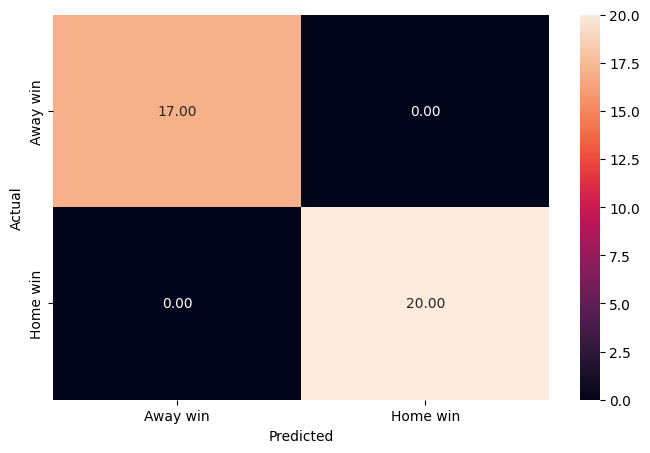

In [ ]:
dt_pred_train = dt.predict(X_train)
metrics_score(y_train, dt_pred_train)

              precision    recall  f1-score   support

           0       1.00      0.62      0.77         8
           1       0.40      1.00      0.57         2

    accuracy                           0.70        10
   macro avg       0.70      0.81      0.67        10
weighted avg       0.88      0.70      0.73        10



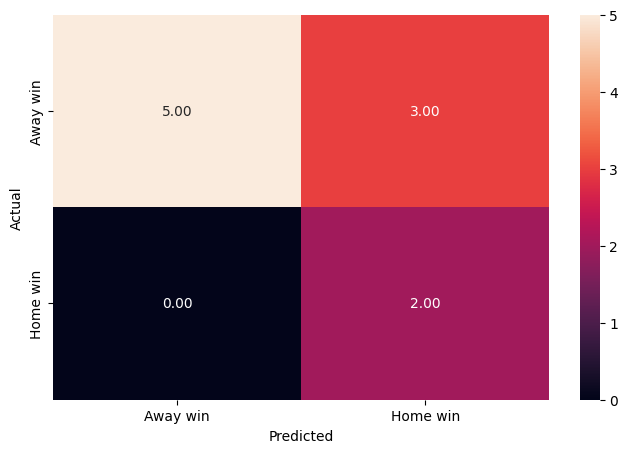

In [ ]:
dt_pred_test = dt.predict(X_test)
metrics_score(y_test, dt_pred_test)

In [ ]:
# grid search for hyperparameters
from sklearn.model_selection import GridSearchCV
# tuning the decision tree
df_tuned = DecisionTreeClassifier(random_state=0)
parameters = {
                'max_depth':[4, 6, 8, 10, None],
                'max_features': ['sqrt','log2',None],
                'criterion': ['gini','entropy'],
            }

cv = GridSearchCV(df_tuned,param_grid = parameters,cv = 5)
cv.fit(X_train,y_train)
cv.score(X_test,y_test)
cv.best_params_

{'criterion': 'gini', 'max_depth': 4, 'max_features': None}

In [ ]:
# tuned dt
dt_tuned = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=0)
dt_tuned.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=0)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        20

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



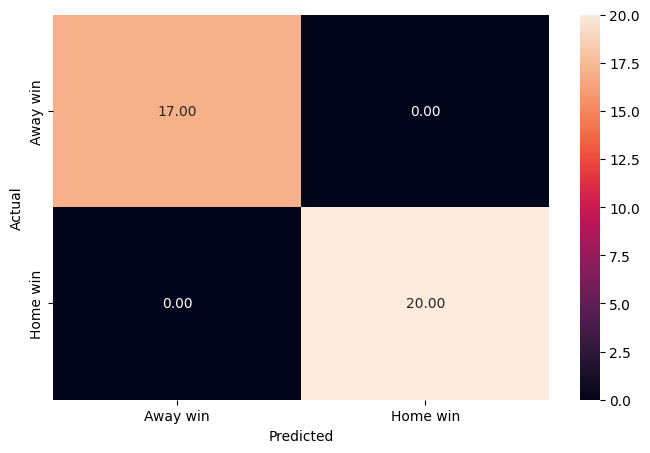

In [ ]:
# metric score for train
dt_tuned_pred_train = dt_tuned.predict(X_train)
metrics_score(y_train, dt_tuned_pred_train)

              precision    recall  f1-score   support

           0       1.00      0.62      0.77         8
           1       0.40      1.00      0.57         2

    accuracy                           0.70        10
   macro avg       0.70      0.81      0.67        10
weighted avg       0.88      0.70      0.73        10



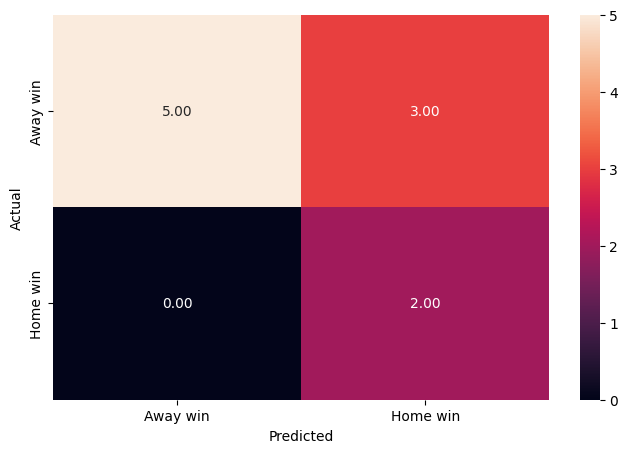

In [ ]:
# metric score for test
dt_tuned_pred_test = dt_tuned.predict(X_test)
metrics_score(y_test, dt_tuned_pred_test)

#Random forest

In [ ]:
# random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=0)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        20

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



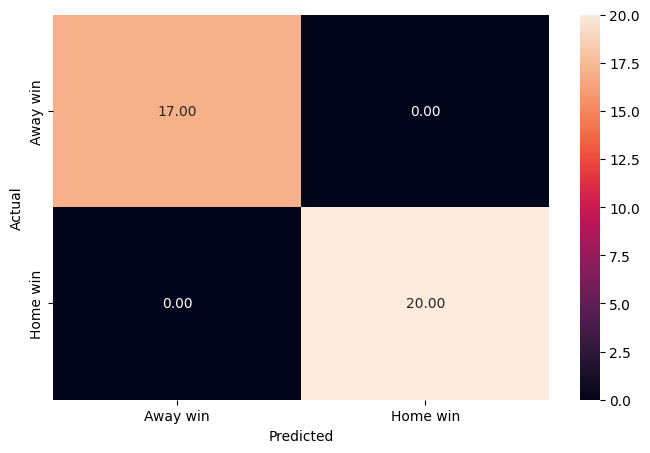

In [ ]:
# metric score for train
rf_pred_train = rf.predict(X_train)
metrics_score(y_train, rf_pred_train)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



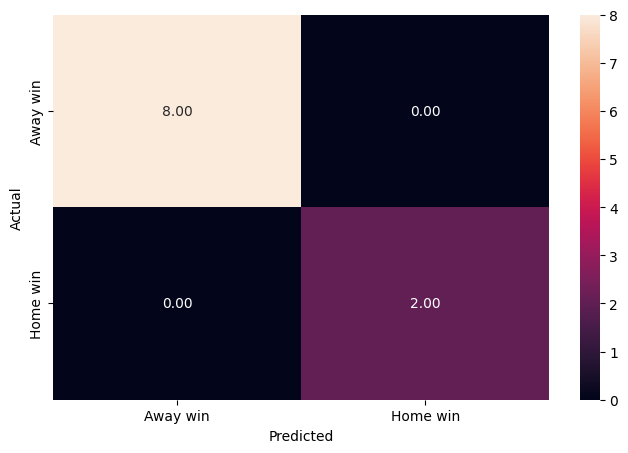

In [ ]:
# metric score for test
rf_pred_test = rf.predict(X_test)
metrics_score(y_test, rf_pred_test)

In [ ]:
# tuning random forest
# grid search to find optimal hyperparameters for rf
rf_tuned = RandomForestClassifier(random_state=0)
params_rf = {
        "n_estimators": [100, 250, 500],
        "min_samples_leaf": np.arange(1, 4, 1),
        "max_features": [0.7, 0.9],
}

cv_rf = GridSearchCV(rf_tuned,param_grid = params_rf,cv = 5)
cv_rf.fit(X_train,y_train)
cv_rf.score(X_test,y_test)
cv_rf.best_params_

{'max_features': 0.7, 'min_samples_leaf': 1, 'n_estimators': 100}

In [ ]:
# tuned rf
rf_tuned = RandomForestClassifier(max_features=0.7, min_samples_leaf=1, n_estimators=500, random_state=0)
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(max_features=0.7, n_estimators=500, random_state=0)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        20

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



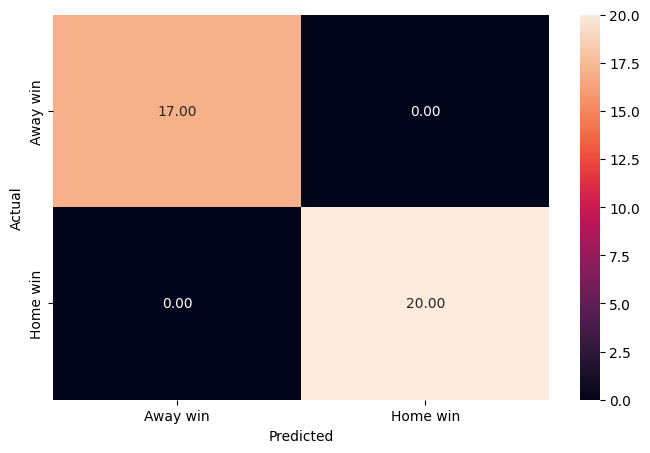

In [ ]:
# metric score for train
rf_tuned_pred_train = rf_tuned.predict(X_train)
metrics_score(y_train, rf_tuned_pred_train)

              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.67      1.00      0.80         2

    accuracy                           0.90        10
   macro avg       0.83      0.94      0.87        10
weighted avg       0.93      0.90      0.91        10



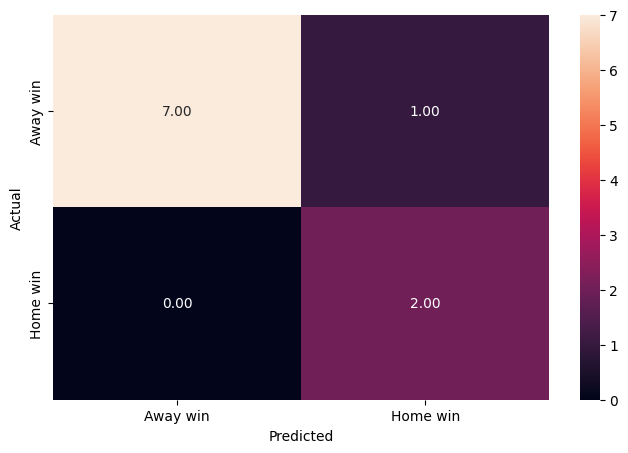

In [ ]:
# metric score for test
rf_tuned_pred_test = rf_tuned.predict(X_test)
metrics_score(y_test, rf_tuned_pred_test)

In [ ]:
df_new.columns

Index(['home_team', 'visit_team', 'home_1', 'home_2', 'home_3', 'visit_1',
       'visit_2', 'visit_3', 'home_pp_elapsed_1', 'home_pp_shots_1',
       'home_pp_oppshots_1', 'home_pp_elapsed_2', 'home_pp_shots_2',
       'home_pp_oppshots_2', 'home_pp_elapsed_3', 'home_pp_shots_3',
       'home_pp_oppshots_3', 'visit_pp_elapsed_1', 'visit_pp_shots_1',
       'visit_pp_oppshots_1', 'visit_pp_elapsed_2', 'visit_pp_shots_2',
       'visit_pp_oppshots_2', 'visit_pp_elapsed_3', 'visit_pp_shots_3',
       'visit_pp_oppshots_3', 'home_A', 'home_shots_p1', 'home_shots_p2',
       'home_shots_p3', 'home_BLK', 'visit_A', 'visit_shots_p1',
       'visit_shots_p2', 'visit_shots_p3', 'visit_BLK', 'home_faceoff_w',
       'visit_faceoff_w', 'home_OT 1', 'visit_OT 1', 'visit_pp_elapsed_4',
       'visit_pp_shots_4', 'visit_pp_oppshots_4', 'home_shots_p4',
       'visit_shots_p4', 'home_OT 2', 'visit_OT 2', 'home_shots_p5',
       'visit_shots_p5', 'home_W', 'home_saves_1', 'home_saves_2',
       'home

In [ ]:
df_new.columns

Index(['home_team', 'visit_team', 'home_1', 'home_2', 'home_3', 'visit_1',
       'visit_2', 'visit_3', 'home_pp_elapsed_1', 'home_pp_shots_1',
       'home_pp_oppshots_1', 'home_pp_elapsed_2', 'home_pp_shots_2',
       'home_pp_oppshots_2', 'home_pp_elapsed_3', 'home_pp_shots_3',
       'home_pp_oppshots_3', 'visit_pp_elapsed_1', 'visit_pp_shots_1',
       'visit_pp_oppshots_1', 'visit_pp_elapsed_2', 'visit_pp_shots_2',
       'visit_pp_oppshots_2', 'visit_pp_elapsed_3', 'visit_pp_shots_3',
       'visit_pp_oppshots_3', 'home_A', 'home_shots_p1', 'home_shots_p2',
       'home_shots_p3', 'home_BLK', 'visit_A', 'visit_shots_p1',
       'visit_shots_p2', 'visit_shots_p3', 'visit_BLK', 'home_faceoff_w',
       'visit_faceoff_w', 'home_OT 1', 'visit_OT 1', 'visit_pp_elapsed_4',
       'visit_pp_shots_4', 'visit_pp_oppshots_4', 'home_shots_p4',
       'visit_shots_p4', 'home_OT 2', 'visit_OT 2', 'home_shots_p5',
       'visit_shots_p5', 'home_W', 'home_saves_1', 'home_saves_2',
       'home

In [ ]:
# get dummy variables for df_new
df_new = pd.get_dummies(df_new, drop_first=True)

In [ ]:
df_new.columns

Index(['home_1', 'home_2', 'home_3', 'visit_1', 'visit_2', 'visit_3',
       'home_pp_elapsed_1', 'home_pp_shots_1', 'home_pp_oppshots_1',
       'home_pp_elapsed_2', 'home_pp_shots_2', 'home_pp_oppshots_2',
       'home_pp_elapsed_3', 'home_pp_shots_3', 'home_pp_oppshots_3',
       'visit_pp_elapsed_1', 'visit_pp_shots_1', 'visit_pp_oppshots_1',
       'visit_pp_elapsed_2', 'visit_pp_shots_2', 'visit_pp_oppshots_2',
       'visit_pp_elapsed_3', 'visit_pp_shots_3', 'visit_pp_oppshots_3',
       'home_A', 'home_shots_p1', 'home_shots_p2', 'home_shots_p3', 'home_BLK',
       'visit_A', 'visit_shots_p1', 'visit_shots_p2', 'visit_shots_p3',
       'visit_BLK', 'home_faceoff_w', 'visit_faceoff_w', 'home_OT 1',
       'visit_OT 1', 'visit_pp_elapsed_4', 'visit_pp_shots_4',
       'visit_pp_oppshots_4', 'home_shots_p4', 'visit_shots_p4', 'home_OT 2',
       'visit_OT 2', 'home_shots_p5', 'visit_shots_p5', 'home_W',
       'home_saves_1', 'home_saves_2', 'home_saves_3', 'visit_saves_1',
      

#Poisson

#Predictions

In [ ]:
def predict_game(away_name, home_name):
    try:
        # use the model
        model = rf_tuned

        # Check if the teams are in the data
        home_team_col = f'home_team_{home_name}'
        away_team_col = f'visit_team_{away_name}'

        home_not_found = home_team_col not in df_new.columns
        away_not_found = away_team_col not in df_new.columns

        # setting up ythe new dataframes and handling if the data was not found
        if not home_not_found:
            df_home = df_new[df_new[home_team_col] == 1]
        else:
            df_home = pd.DataFrame()

        if not away_not_found:
            df_away = df_new[df_new[away_team_col] == 1]
        else:
            df_away = pd.DataFrame()

        # feature names from the model
        feature_names = model.feature_names_in_

        # splitting feature names into home and away features
        home_features = [f for f in feature_names if f.startswith('home_')]
        away_features = [f for f in feature_names if f.startswith('visit_')]

        # Calculate averages for all features
        numeric_cols = df_new.select_dtypes(include='number').columns
        averages = df_new[numeric_cols].mean().to_dict()

        # home stats, handles if home was not found
        if home_not_found:
            home_stats = [averages.get(col, 0) for col in home_features]
        else:
            home_stats = [df_home[col].iloc[-1] if col in df_home.columns else averages.get(col, 0) for col in home_features]

        # visit stats, handles if away was not found
        if away_not_found:
            away_stats = [averages.get(col, 0) for col in away_features]
        else:
            away_stats = [df_away[col].iloc[-1] if col in df_away.columns else averages.get(col, 0) for col in away_features]

        # Combine the stats into a single list for prediction
        new_stats = away_stats + home_stats

        # Create a DataFrame for the new game data
        df_predict = pd.DataFrame([new_stats], columns=feature_names)

        # Predict the probability of the home and visit team winning using the model
        probabilities = model.predict_proba(df_predict)[0]

        # Probability of the home team winning
        home_win_prob = probabilities[1]
        away_win_prob = probabilities[0]

        # Determine the winner and return the prediction with win probabilities
        if home_win_prob > away_win_prob:
            win_prob = str(round(home_win_prob * 100, 1)) + '%'
            return f'The home team ({home_name}) has a {win_prob} chance of winning'
        else:
            win_prob = str(round(away_win_prob * 100, 1)) + '%'
            return f'The away team ({away_name}) has a {win_prob} chance of winning'

    except Exception as e:
        return f"Unable to predict the game due to an error: {str(e)}"



In [ ]:
predict_game("Providence", "Northeastern")

'The home team (Northeastern) has a 64.2% chance of winning'